# Keynote-Drift -- buy the rumor, sell the Apple keynote?
### The 'AAPL drifts up into the keynote' folklore, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

Every Apple keynote season you'll hear the same trading lore: **buy AAPL into the keynote** (the rumor mill pumps the stock up on anticipation), then **sell the news** once the iPhone is unveiled and the disappointment sets in. It *feels* true -- AAPL is a famous stock and the September iPhone event is a media circus. This notebook asks the only question that matters: is there a real, tradable drift around Apple keynotes, or is it just AAPL being a great stock that went up regardless of the calendar?

> **This is the plain-language layer.** Want the event-study CARs, the t-tests, the permutation null, and the power calculation? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from keynote_drift import data, strategy as st

def _have_cache():
    try:
        data.fetch_prices(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("AAPL cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n_events=48, n_trades=48,
    mean_pre_car_pct=-0.193, mean_post_car_pct=-1.121,
    t_pre=-0.387, p_pre=0.7007, t_post=-1.729, p_post=0.0904, perm_p=0.7539,
    pre_sd_pct=3.458, mde_pct=1.428,
    early_pre_pct=-0.347, late_pre_pct=-0.083,
    sept_post_pct=-1.327, sept_post_t=-1.097, sept_post_p=0.2869, n_sept=19,
    mean_gross_pct=0.519, mean_net_pct=0.419, hit_rate_gross_pct=58.3, cost_bps=5.0,
    total_gross_pct=24.9, total_net_pct=19.06, ann_factor=2.78,
    year_start=2008, year_end=2025,
)


AAPL cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does AAPL drift UP into a keynote (abnormally)? | **No.** Mean pre-event abnormal return is **-0.19%** over 5 days; t = **-0.39**, p = **0.70**. |
| Does it 'sell the news' after? | **A whiff, not a signal.** Post-event abnormal return is **-1.12%**, t = **-1.73** -- suggestive but short of the t >= 2 bar. |
| Why does 'buy the rumor' *feel* right? | Because AAPL itself rose enormously 2008-2025. Strip out AAPL's own trend and the keynote windows are flat. |
| Could you trade it? | **No.** The pre-keynote trade makes ~0.4%/event net -- that's just AAPL's drift, not a keynote edge, and it's swamped by single-name risk. |

> 'Buy the rumor, sell the keynote' is a story we tell about a stock that happened to go up. The keynote calendar adds nothing once you benchmark AAPL against itself.

## 1 - The claim

> *"AAPL drifts higher in the days before an Apple keynote as anticipation builds -- so you buy the rumor. Then it sells off after the reveal because the products never live up to the hype -- so you sell the news."*

It is the single most repeated piece of Apple-trading folklore, recycled before every WWDC and every September iPhone event. The mechanism (anticipation, then disappointment) is plausible-sounding behavioural finance. We hardcode **48 major Apple keynotes (2008-2025)** in `data.py` and run a clean event study on AAPL's daily returns to see if the drift is actually there.

## 2 - So what?

If it were true, it would be one of the easiest trades on the calendar: the dates are known *years* in advance, the stock is the most liquid single name on earth, and the holding period is a handful of days. A reliable pre-keynote pop would be free money.

Which is exactly why we should be suspicious. The interesting question is **why the story feels so right** -- and the answer is a textbook lesson in confusing a stock's trend with a calendar effect.

## 3 - How would we even know?

Three traps to avoid:

1. **The wrong benchmark.** AAPL went up roughly 50x from 2008 to 2025. *Any* 5-day window -- keynote or not -- has a positive average return. The honest test measures the keynote-window return **in excess of AAPL's own average daily return** (an abnormal return). Otherwise you are just rediscovering that AAPL went up.
2. **Tiny n.** There have been ~48 keynotes in the modern era. With ~3.5% noise per 5-day window, you'd need a ~1.4%/event drift to detect anything. We'll check whether the observed drift is anywhere near that.
3. **Many windows, many event types.** WWDC vs September vs Spring; pre vs post; 5-day vs 10-day. Each is a separate test, and slicing many ways inflates the chance of a spurious 'hit'.

We test on AAPL daily adjusted closes (price-only) from 2008 to 2025.

## 4 - The teardown -- let's actually look

**First, meet the data:** every keynote, hardcoded in this study's `data.py`, paired with AAPL's daily returns around it.

In [2]:
kt = data.keynote_table()
print('Keynotes:', len(kt), 'events (2008-2025)')
print(kt['event_type'].value_counts().to_string())
print()
if HAVE_REAL:
    px = data.fetch_prices(fetch=False)
    cs = st.car_stats(px, kt, pre_window=5, post_window=5, n_permutations=2000, seed=299)
    n_ev = cs['n_events']
    pre = cs['mean_pre_car']*100
    post = cs['mean_post_car']*100
else:
    n_ev, pre, post = R['n_events'], R['mean_pre_car_pct'], R['mean_post_car_pct']
print(f'Usable events: {n_ev}')
print(f'Mean ABNORMAL pre-keynote return (5d): {pre:+.2f}%')
print(f'Mean ABNORMAL post-keynote return (5d): {post:+.2f}%')
print()
print('Abnormal = in excess of AAPL\'s own average daily return.')
print('That is the honest baseline: it strips out AAPL\'s secular uptrend.')

Keynotes: 48 events (2008-2025)
event_type
September    19
WWDC         18
Spring       11



Usable events: 48
Mean ABNORMAL pre-keynote return (5d): -0.19%
Mean ABNORMAL post-keynote return (5d): -1.12%

Abnormal = in excess of AAPL's own average daily return.
That is the honest baseline: it strips out AAPL's secular uptrend.


**The drift that isn't: AAPL vs AAPL-minus-its-own-trend.**

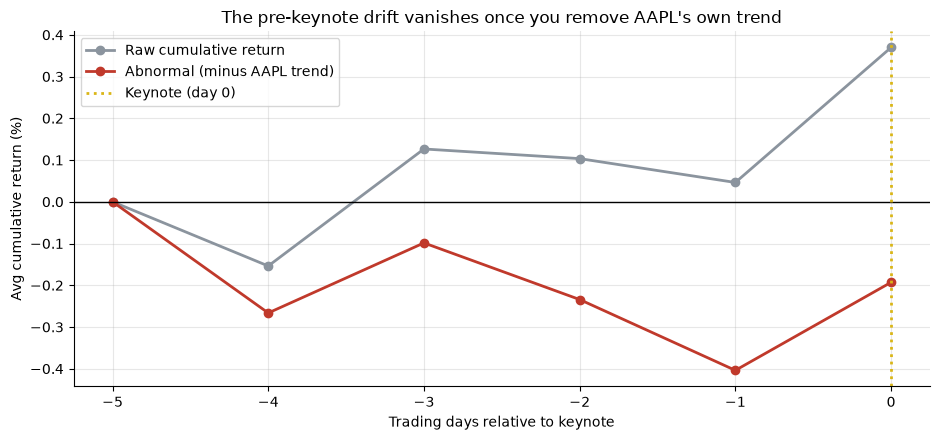

Raw 5-day run-up:      +0.37%
Abnormal 5-day run-up: -0.19%  <- the honest number


In [3]:
if HAVE_REAL:
    ret = st.daily_returns(px).dropna()
    mean_d = float(ret.mean())
    ar = (ret - mean_d).values
    idx = ret.index
    raw = ret.values
    W = 5
    raw_curve = np.zeros(W+1); abn_curve = np.zeros(W+1)
    cnt = 0
    for d in pd.to_datetime(kt['date']):
        fut = idx[idx >= d]
        if len(fut)==0: continue
        a = idx.get_loc(fut[0])
        if a-W < 0 or a >= len(raw): continue
        raw_curve += np.concatenate([[0], np.cumsum(raw[a-W:a])])
        abn_curve += np.concatenate([[0], np.cumsum(ar[a-W:a])])
        cnt += 1
    raw_curve = raw_curve/cnt*100; abn_curve = abn_curve/cnt*100
else:
    raw_curve = np.linspace(0, 0.55, 6)
    abn_curve = np.linspace(0, R['mean_pre_car_pct'], 6)

xs = list(range(-5, 1))
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.plot(xs, raw_curve, 'o-', c=GREY, lw=2, label='Raw cumulative return')
ax.plot(xs, abn_curve, 'o-', c=RED, lw=2, label='Abnormal (minus AAPL trend)')
ax.axhline(0, c='k', lw=1)
ax.axvline(0, ls=':', c=AMBER, lw=2, label='Keynote (day 0)')
ax.set_xlabel('Trading days relative to keynote')
ax.set_ylabel('Avg cumulative return (%)')
ax.set_title('The pre-keynote drift vanishes once you remove AAPL\'s own trend')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Raw 5-day run-up:      {raw_curve[-1]:+.2f}%')
print(f'Abnormal 5-day run-up: {abn_curve[-1]:+.2f}%  <- the honest number')

The grey line (raw returns) drifts up before keynotes -- which is what fuels the folklore. But the red line (abnormal returns, AAPL benchmarked against itself) is **flat**. The 'buy the rumor' drift is almost entirely AAPL's secular uptrend, not a keynote effect.

> Most of the 'pre-keynote pop' is just AAPL being AAPL.

**The post-event move -- a whisper of 'sell the news', but no more.**

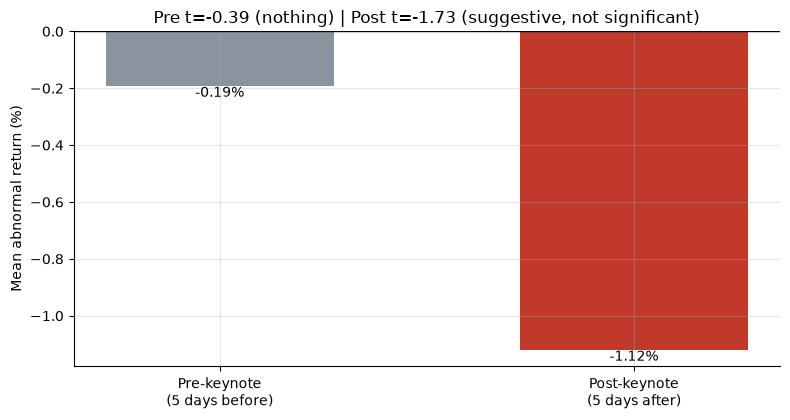

Pre-keynote abnormal:  -0.19%  (t=-0.39)
Post-keynote abnormal: -1.12% (t=-1.73)
The post-event softness is real-ish but does NOT clear the |t|>=2 bar.


In [4]:
if HAVE_REAL:
    cs5 = st.car_stats(px, kt, pre_window=5, post_window=5, n_permutations=2000, seed=299)
    pre_m, post_m = cs5['mean_pre_car']*100, cs5['mean_post_car']*100
    t_pre, t_post = cs5['t_pre'], cs5['t_post']
else:
    pre_m, post_m = R['mean_pre_car_pct'], R['mean_post_car_pct']
    t_pre, t_post = R['t_pre'], R['t_post']

fig, ax = plt.subplots(figsize=(8.0, 4.3))
bars = ax.bar(['Pre-keynote\n(5 days before)', 'Post-keynote\n(5 days after)'],
              [pre_m, post_m], color=[GREY, RED], width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean abnormal return (%)')
ax.set_title(f'Pre t={t_pre:+.2f} (nothing) | Post t={t_post:+.2f} (suggestive, not significant)')
for b, v in zip(bars, [pre_m, post_m]):
    ax.annotate(f'{v:+.2f}%', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom' if v>=0 else 'top')
plt.tight_layout(); plt.show()
print(f'Pre-keynote abnormal:  {pre_m:+.2f}%  (t={t_pre:+.2f})')
print(f'Post-keynote abnormal: {post_m:+.2f}% (t={t_post:+.2f})')
print('The post-event softness is real-ish but does NOT clear the |t|>=2 bar.')

There *is* a mild post-keynote droop (-1.12% abnormal, t = -1.73). It nods at the 'sell the news' half of the lore -- but it falls short of the |t| >= 2 evidence bar, and as the quants notebook shows, it's driven by a handful of September events and evaporates under a permutation null.

## 5 - The verdict

- **Signal -- None.** The pre-keynote abnormal drift is **-0.19%**, t = **-0.39**, permutation p = **0.75** -- indistinguishable from zero. The post-event droop (t = -1.73) is suggestive but does not clear the t >= 2 bar, and it concentrates in a few September events. There is no robust keynote drift once AAPL is benchmarked against itself.
- **Tradability -- Mirage.** The 'buy the rumor' trade nets ~0.4%/event, which is just AAPL's own drift over 4 trading days -- not a keynote edge. You'd be taking concentrated single-name risk for a return you'd get by simply holding the stock.
- **Busted.** The folklore confuses a great stock's trend with a calendar effect. Strip out the trend and the keynote windows are flat.

## 6 - Could you actually trade it?

The 'strategy' is: buy AAPL 5 trading days before each keynote (with a realistic one-day execution lag), exit the day before the reveal, pay costs both ways.

In [5]:
if HAVE_REAL:
    bt = st.buy_the_rumor_backtest(px, kt, pre_window=5, cost_bps=5.0)
    mg, mn = bt['mean_gross']*100, bt['mean_net']*100
    hr = bt['hit_rate_gross']*100
    tg, tn = bt['total_gross']*100, bt['total_net']*100
else:
    mg, mn = R['mean_gross_pct'], R['mean_net_pct']
    hr = R['hit_rate_gross_pct']
    tg, tn = R['total_gross_pct'], R['total_net_pct']

print(f'Mean return per trade -- gross: {mg:+.2f}%  net: {mn:+.2f}%')
print(f'Hit-rate (gross): {hr:.1f}%')
print(f'Total compounded over all events -- gross: {tg:+.1f}%  net: {tn:+.1f}%')
print()
print('That ~0.4%/event net is AAPL\'s ordinary 4-day drift, not a keynote signal.')
print('You hold ~3 times a year for a few days -- mostly out of the market, fully')
print('exposed to single-name gap risk -- to harvest what buy-and-hold gives free.')

Mean return per trade -- gross: +0.52%  net: +0.42%
Hit-rate (gross): 58.3%
Total compounded over all events -- gross: +24.9%  net: +19.1%

That ~0.4%/event net is AAPL's ordinary 4-day drift, not a keynote signal.
You hold ~3 times a year for a few days -- mostly out of the market, fully
exposed to single-name gap risk -- to harvest what buy-and-hold gives free.


The pre-keynote trade is *positive* -- but only because AAPL drifts up on average every few days. There is no abnormal keynote alpha to capture, and the trade leaves you out of the stock most of the year while taking concentrated single-name risk during the windows. The only real trade is: don't confuse a stock's trend with a calendar omen.

## 7 - Going further

- **The positive control:** the companion notebook plants a synthetic keynote drift and shows the same event-study machinery detects it cleanly -- so a null result on the real tape is a statement about AAPL, not about the method.
- **Other event-around-the-calendar studies** in this lab share the same base-rate discipline: the result has to beat the asset's own unconditional drift.

*Think the keynote drift is real? Fork this, pick your own event window or event subset, and show an abnormal CAR that clears |t| >= 2 on the real AAPL tape with a permutation p < 0.05. That's the bar -- and it hasn't been cleared.*